# DS 6021 Intro to Predictive Modeling - Lab 3: Feature Selection

## Fiona St. Clair

AI Disclosure: I used Claude AI to help draft and run the code for this lab, along with the in-class notebooks. The interpretation and reasoning in the written answers is my own.
***

## Part 1: Multicollinearity and Multiple Linear Regression

### Question 1 

Last week, we compared three nested models predicting penguin body mass - `flipper_length_mm`, `flipper_length_mm + bill_depth_mm`, and `flipper_length_mm + bill_depth_mm + bill_length_mm` - using R², adjusted R², RSE, and the F-statistic, and I picked model b because it had the highest adjusted R² (0.7596) and the lowest RSE (393.18), even though model c had a very slightly higher raw R². This week, we added a more direct tool for this exact situation: since these three models are nested (each one is the previous model plus one more predictor), we can run a nested F-test (partial F-test, `sm.stats.anova_lm`) that directly tests whether the extra predictors explain a statistically significant amount of additional variation, rather than just comparing summary statistics like adjusted R² by eye.

From this new analysis, yes, my answer changes. The nested F-test compares model a → b and gets F = 2.90, p = 0.089, and it compares model b → c and gets F = 0.61, p = 0.435. At the usual α = 0.05 cutoff, neither additional predictor produces a statistically significant improvement in fit. Adding `bill_depth_mm` to the flipper-only model is only marginal (p = 0.089, not significant at 0.05), and adding `bill_length_mm` on top of that adds essentially nothing (p = 0.435).

Last week I picked model b because its adjusted R² and RSE were numerically the best of the three, but adjusted R² can nudge upward from a predictor that isn't actually pulling its weight statistically. The nested F-test gives a formal hypothesis test (H₀: the added coefficient(s) = 0) for whether that improvement is real or just noise. Applying that stricter standard, the honest answer is that the simplest model a, body_mass_g ~ flipper_length_mm alone, is defensible and I would not confidently justify adding bill depth or bill length based on this data. The earlier choice of model b was reasonable as a "best of the three by the numbers" pick, but it doesn't hold up as "significantly better than the simpler model" once you test it directly.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

penguins = pd.read_csv('../../../data/penguins.csv')
cols_needed = ['flipper_length_mm', 'bill_depth_mm', 'bill_length_mm', 'body_mass_g']
df_model = penguins.dropna(subset=cols_needed)

y = df_model['body_mass_g']
model_a = sm.OLS(y, sm.add_constant(df_model[['flipper_length_mm']])).fit()
model_b = sm.OLS(y, sm.add_constant(df_model[['flipper_length_mm', 'bill_depth_mm']])).fit()
model_c = sm.OLS(y, sm.add_constant(df_model[['flipper_length_mm', 'bill_depth_mm', 'bill_length_mm']])).fit()

nested_test = sm.stats.anova_lm(model_a, model_b, model_c)
nested_test

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,340.0,5.285480e+07,0.0,NaN,NaN,NaN
1,339.0,5.240575e+07,1.0,449043.646743,2.901411,0.089419
2,338.0,5.231136e+07,1.0,94393.101155,0.609903,0.435371


### Question 2

#### a. Correlation matrix and heatmap

In [2]:
bike = pd.read_csv('../../../data/bike-sharing-daily.csv')

corr = bike[['cnt', 'temp', 'hum', 'windspeed']].corr()
corr.round(3)

,cnt,temp,hum,windspeed
cnt,1.000,0.627,-0.101,-0.235
temp,0.627,1.000,0.127,-0.158
hum,-0.101,0.127,1.000,-0.248
windspeed,-0.235,-0.158,-0.248,1.000


Unlike `temp` and `atemp` (which we saw are correlated around 0.99), none of `temp`, `hum`, and `windspeed` are highly correlated with each other. The strongest pairwise correlation among the predictors is `hum`/`windspeed` at -0.248, which is weak. 

`temp` is the only variable strongly correlated with `cnt` itself (0.627); `hum` and `windspeed` are only weakly correlated with `cnt`. So at first glance, multicollinearity does not look like it will be a problem for this particular set of predictors.

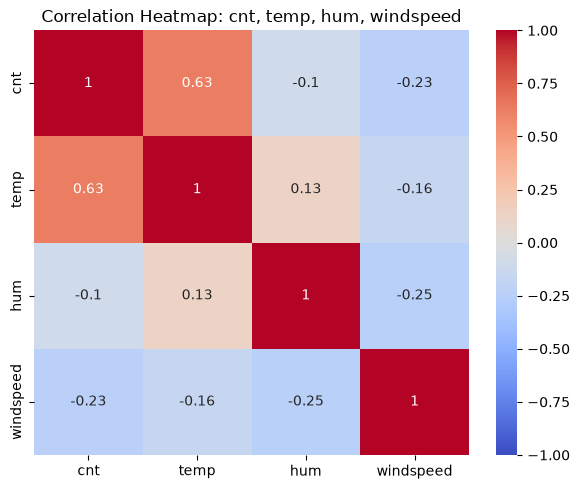

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: cnt, temp, hum, windspeed')
plt.tight_layout()
plt.show()

#### b. Linear model and VIF

All three VIFs are very close to 1 (temp: 1.03, hum: 1.08, windspeed: 1.09), far below the  cutoff of 5, confirming what the correlation matrix suggested: there's essentially no multicollinearity among these three predictors, so their coefficient estimates and standard errors can be trusted at face value.

Interpreting each coefficient (holding the other two fixed):
- **temp** (+6625.5): a one-unit increase in normalized temperature is associated with about 6626 more bike rentals per day, on average. This matches intuition - warmer weather means more people are willing to bike.
- **hum** (-3100.1): a one-unit increase in normalized humidity is associated with about 3100 fewer rentals per day. This also matches intuition - muggy, humid conditions are less pleasant to bike in.
- **windspeed** (-4806.9): a one-unit increase in normalized windspeed is associated with about 4807 fewer rentals per day, which again matches intuition, since windy conditions make biking harder and less appealing.

All three effects are highly significant (p < 0.001) and all three signs line up with what I'd expect before even looking at the data.

In [4]:
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

bike_model = smf.ols('cnt ~ temp + hum + windspeed', data=bike).fit()
print(bike_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     207.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.26e-97
Time:                        16:41:29   Log-Likelihood:                -6343.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.271e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4084.3634    337.862     12.089      0.0

In [5]:
preds = ['temp', 'hum', 'windspeed']
X = sm.add_constant(bike[preds])
vif = pd.DataFrame({
    'variable': preds,
    'VIF': [variance_inflation_factor(X.values, X.columns.get_loc(c)) for c in preds],
})
vif.round(3)

,variable,VIF
0,temp,1.034
1,hum,1.075
2,windspeed,1.085


#### c. Nested F-test across three models

In [6]:
m1 = smf.ols('cnt ~ temp', data=bike).fit()
m2 = smf.ols('cnt ~ temp + hum', data=bike).fit()
m3 = smf.ols('cnt ~ temp + hum + windspeed', data=bike).fit()

bike_nested = sm.stats.anova_lm(m1, m2, m3)
bike_nested

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,729.0,1.660847e+09,0.0,NaN,NaN,NaN
1,728.0,1.570304e+09,1.0,9.054330e+07,44.569779,4.869005e-11
2,727.0,1.476897e+09,1.0,9.340630e+07,45.979085,2.475445e-11


In [7]:
summary_table = pd.DataFrame({
    'Model': ['cnt ~ temp', 'cnt ~ temp + hum', 'cnt ~ temp + hum + windspeed'],
    'R2': [m1.rsquared, m2.rsquared, m3.rsquared],
    'Adj R2': [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    'RSE': [np.sqrt(m1.mse_resid), np.sqrt(m2.mse_resid), np.sqrt(m3.mse_resid)],
    'F-stat': [m1.fvalue, m2.fvalue, m3.fvalue],
})
summary_table.round(3)

,Model,R2,Adj R2,RSE,F-stat
0,cnt ~ temp,0.394,0.393,1509.388,473.472
1,cnt ~ temp + hum,0.427,0.425,1468.676,271.031
2,cnt ~ temp + hum + windspeed,0.461,0.459,1425.305,207.177


Unlike the penguin models in Question 1, here **both** additions are statistically significant: adding `hum` to the temp-only model gives F = 44.57, p ≈ 4.9e-11, and adding `windspeed` on top of that gives F = 45.98, p ≈ 2.5e-11. Both p-values are far below 0.05, so each added predictor meaningfully reduces the residual sum of squares beyond what we'd expect from noise alone.

#### d. Which model would I choose?

I would choose the full model, cnt ~ temp + hum + windspeed. The nested F-test shows both `hum` and `windspeed` add statistically significant explanatory power on top of the simpler models. This is also consistent with the adjusted R² increasing at every step (0.393 → 0.425 → 0.459) and the RSE decreasing at every step (1509 → 1469 → 1425), so every metric points the same direction. Combined with the fact that the VIFs showed no meaningful multicollinearity between these three predictors, there's no reason to leave any of them out.
***

## Part 2: Categorical Predictors and Interaction Terms

### Question 1 

In [8]:
df_model_sex = df_model.dropna(subset=['sex'])
print("n before dropping sex:", len(df_model))
print("n after dropping sex:", len(df_model_sex))

full_342 = model_c  # same model from Part 1: flipper + bill_depth + bill_length, n=342
full_333 = smf.ols("body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm", data=df_model_sex).fit()

full_342_params = full_342.params.rename({'const': 'Intercept'})
pd.DataFrame({'n=342': full_342_params, 'n=333': full_333.params}).round(2)

n before dropping sex: 342
n after dropping sex: 333


,n=342,n=333
Intercept,-6424.76,-6445.48
flipper_length_mm,50.27,50.76
bill_depth_mm,20.05,17.84
bill_length_mm,4.16,3.29


In [9]:
print("R2:", round(full_342.rsquared, 4), round(full_333.rsquared, 4))
print("Adj R2:", round(full_342.rsquared_adj, 4), round(full_333.rsquared_adj, 4))

R2: 0.7615 0.7639
Adj R2: 0.7594 0.7618


Not really, no. The coefficients move around a little bit (bill_depth goes from about 20.05 to 17.84, bill_length drops a little too), but nothing huge. R² barely changes (0.7615 to 0.7639), and adjusted R² barely moves either (0.759 to 0.762). So dropping those 9 penguins doesn't change the story the model is telling - it's basically the same model either way.

### Question 2

In [10]:
flip_only = smf.ols("body_mass_g ~ flipper_length_mm", data=df_model_sex).fit()
additive_sex = smf.ols("body_mass_g ~ flipper_length_mm + C(sex)", data=df_model_sex).fit()
interaction_sex = smf.ols("body_mass_g ~ flipper_length_mm * C(sex)", data=df_model_sex).fit()

table1 = pd.DataFrame({
    "Model": ["flipper only", "flipper + sex (additive)", "flipper * sex (interactive)"],
    "R2": [flip_only.rsquared, additive_sex.rsquared, interaction_sex.rsquared],
    "Adj R2": [flip_only.rsquared_adj, additive_sex.rsquared_adj, interaction_sex.rsquared_adj],
})
table1.round(4)

,Model,R2,Adj R2
0,flipper only,0.7621,0.7614
1,flipper + sex (additive),0.8058,0.8047
2,flipper * sex (interactive),0.8058,0.8041


In [11]:
sm.stats.anova_lm(flip_only, additive_sex, interaction_sex)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,331.0,5.121196e+07,0.0,NaN,NaN,NaN
1,330.0,4.179537e+07,1.0,9.416589e+06,74.126700,3.050629e-16
2,329.0,4.179409e+07,1.0,1.286001e+03,0.010123,9.199177e-01


#### a. Which model is best?

Going from flipper-only to the additive model (adding sex) is a big jump - the nested F-test gives F = 74.13 with a p-value that's basically zero, so sex is definitely adding real information. But going from additive to interactive barely changes anything at all (F = 0.01, p = 0.92), and the interactive model's adjusted R² (0.8041) is actually a hair lower than the additive one (0.8047). So I'd pick the **additive model** (flipper_length_mm + C(sex)) - it's simpler and does just as good a job.

In [12]:
additive_sex.params.round(2)

Intercept           -5410.30
C(sex)[T.male]        347.85
flipper_length_mm      46.98
dtype: float64

#### b. What's the effect of sex?

The coefficient on `C(sex)[T.male]` is about +348. That means for two penguins with the same flipper length, a male penguin is predicted to weigh about 348 grams more than a female penguin, on average. Since the interactive model didn't really change anything (the slope for flipper length only differs by about -0.29 g/mm between sexes, and that's not significant), sex looks like it just shifts body mass up or down by a fixed amount and doesn't change how flipper length relates to body mass.

#### c. Plot

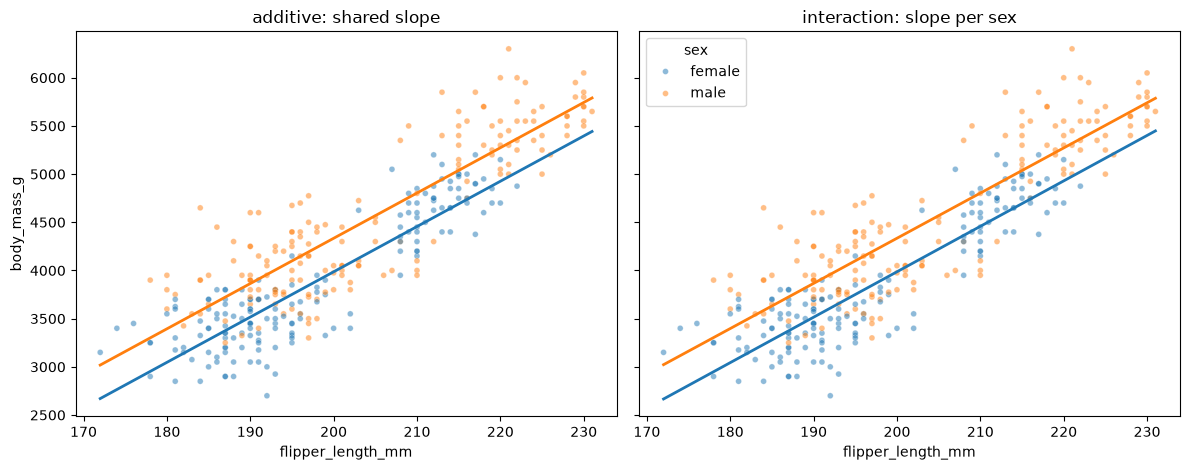

In [13]:
species_or_sex = sorted(df_model_sex.sex.unique())
palette = dict(zip(species_or_sex, sns.color_palette(n_colors=len(species_or_sex))))
grid = np.linspace(df_model_sex.flipper_length_mm.min(), df_model_sex.flipper_length_mm.max(), 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, model, title in [(axes[0], additive_sex, "additive: shared slope"),
                          (axes[1], interaction_sex, "interaction: slope per sex")]:
    sns.scatterplot(data=df_model_sex, x="flipper_length_mm", y="body_mass_g",
                     hue="sex", hue_order=species_or_sex, palette=palette,
                     alpha=0.5, s=18, ax=ax, legend=(ax is axes[1]))
    for s in species_or_sex:
        pred = model.predict(pd.DataFrame({"flipper_length_mm": grid, "sex": s}))
        ax.plot(grid, pred, lw=2, color=palette[s])
    ax.set_title(title)
plt.tight_layout()
plt.show()

Looking at the two plots side by side, the male and female lines in the additive plot (left) are just shifted versions of each other with the same slope, and the interaction plot (right) barely looks any different. The two lines there are basically parallel too. That matches what we determined earlier, that sex mostly just moves the line up or down, it doesn't change the slope in any real way.

### Question 3

In [14]:
additive_ss = smf.ols("body_mass_g ~ C(sex) + C(species)", data=df_model_sex).fit()
interaction_ss = smf.ols("body_mass_g ~ C(sex) * C(species)", data=df_model_sex).fit()

print("R2:", round(additive_ss.rsquared, 4), round(interaction_ss.rsquared, 4))
print("Adj R2:", round(additive_ss.rsquared_adj, 4), round(interaction_ss.rsquared_adj, 4))
sm.stats.anova_lm(additive_ss, interaction_ss)

R2: 0.8468 0.8546
Adj R2: 0.8454 0.8524


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,329.0,3.297919e+07,0.0,NaN,NaN,NaN
1,327.0,3.130263e+07,2.0,1.676557e+06,8.756997,0.000197


#### a. Which model is better?

The nested F-test gives F = 8.76 with p = 0.0002, and the interactive model has a higher adjusted R² too (0.852 vs 0.845). So I'd pick the interactive model because the effect of sex on body mass isn't the same across all three species.

In [15]:
interaction_ss.params.round(2)

Intercept                                 3368.84
C(sex)[T.male]                             674.66
C(species)[T.Chinstrap]                    158.37
C(species)[T.Gentoo]                      1310.91
C(sex)[T.male]:C(species)[T.Chinstrap]    -262.89
C(sex)[T.male]:C(species)[T.Gentoo]        130.44
dtype: float64

#### b. Interpreting the coefficients

Since both predictors here are categories, every coefficient is really just comparing group averages. The reference group is Adelie females, and the intercept (3368.84) is their average body mass. Then:
- Adelie males weigh about 674.66g more than Adelie females on average.
- Chinstrap females weigh about 158.37g more than Adelie females.
- Gentoo females weigh about 1310.91g more than Adelie females.

The interaction terms show that the "male bonus" isn't the same for every species. For Chinstraps, the male bump is about 262.89g smaller than it is for Adelies. For Gentoos, the male bump is about 130.44g bigger than it is for Adelies.

#### c. Plot

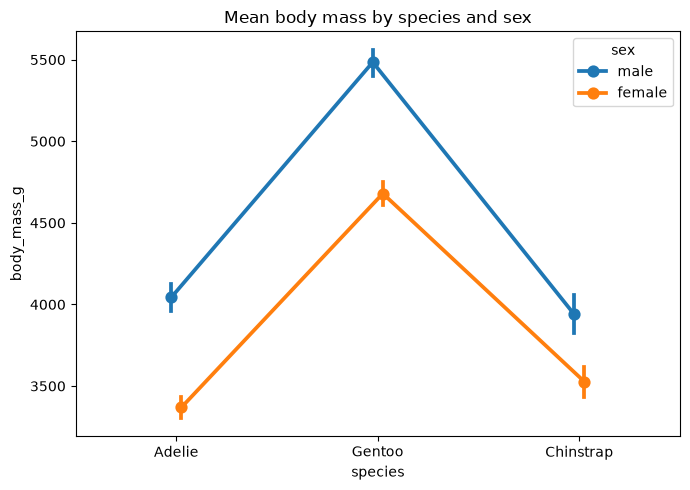

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.pointplot(data=df_model_sex, x="species", y="body_mass_g", hue="sex",
              dodge=True, errorbar=('ci', 95), ax=ax)
ax.set_title("Mean body mass by species and sex")
plt.tight_layout()
plt.show()

If sex had the exact same effect for every species, the male and female dots would be the same distance apart for all three species (the two lines would be parallel). But you can see the gap between the male and female dots is a lot bigger for Gentoo than it is for Chinstrap.

### Question 4

In [17]:
casual_add = smf.ols("casual ~ temp + C(workingday) + hum + windspeed", data=bike).fit()
casual_int = smf.ols("casual ~ temp * C(workingday) + hum + windspeed", data=bike).fit()
sm.stats.anova_lm(casual_add, casual_int)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,726.0,1.276423e+08,0.0,NaN,NaN,NaN
1,725.0,1.103186e+08,1.0,1.732378e+07,113.849712,8.681452e-25


#### a. Casual riders

Adding the interaction between temp and working day makes a big difference. F = 113.85, p is basically zero. So the interactive model is a lot better for casual riders.

On days off (workingday = 0), the effect of temp on casual ridership is huge (+3354.73 per unit of temp). On working days, that effect is a lot smaller: 3354.73 - 1792.45 = about 1562.28. This makes sense, as casual riders are probably mostly leisure riders, and they're way more likely to go biking on a nice day off than a nice workday.

In [18]:
casual_int.params.round(2)

Intercept                   492.57
C(workingday)[T.1]           68.42
temp                       3354.73
temp:C(workingday)[T.1]   -1792.45
hum                        -840.44
windspeed                 -1102.39
dtype: float64

In [19]:
reg_add = smf.ols("registered ~ temp + C(workingday) + hum + windspeed", data=bike).fit()
reg_int = smf.ols("registered ~ temp * C(workingday) + hum + windspeed", data=bike).fit()
sm.stats.anova_lm(reg_add, reg_int)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,726.0,1.020706e+09,0.0,NaN,NaN,NaN
1,725.0,1.016851e+09,1.0,3.855347e+06,2.748806,0.09776


#### b. Registered riders

For registered riders, the interaction barely matters. F = 2.75, p = 0.098, not significant. So the additive model is good enough here, which matches what we talked about in class.

#### c. What is this telling us?

Together, this says temperature's effect on ridership depends a lot on who's riding. Casual riders are way more sensitive to temperature on their days off than on workdays. Registered riders (like commuters) bike about the same amount regardless of the temp/workday combo. This is a good example of how looking at `cnt` as a whole can hide something real going on underneath. In class we found no significant temp/workingday interaction for the total count, but that's probably because it's a mix of these two very different behaviors that partly cancel each other out.

#### d. Why two separate models instead of adding these into the original model?

Because `cnt` is quite literally just `casual + registered` added together. If we tried to use `casual` and `registered` as predictors of `cnt`, we'd just be reconstructing `cnt` from its own pieces and it wouldn't tell us anything useful. Building two separate models instead lets us see two different behaviors that get hidden once they're combined into one count.
***

## Part 3: Outliers, Leverage, and Influence

### Question 1

#### a & b. DataFrame + cutoffs, and how many penguins cross them

In [20]:
from statsmodels.stats.outliers_influence import OLSInfluence

infl = OLSInfluence(model_c)

diag = pd.DataFrame({
    "actual": df_model.body_mass_g,
    "predicted": model_c.fittedvalues,
    "student_resid": infl.resid_studentized_external,
    "leverage": infl.hat_matrix_diag,
    "cooks_d": infl.cooks_distance[0],
})
diag.head(10).round(3)

,actual,predicted,student_resid,leverage,cooks_d
0,3750.0,3211.618,1.376,0.009,0.004
1,3800.0,3438.564,0.922,0.007,0.002
2,3250.0,3906.346,-1.677,0.005,0.003
4,3450.0,3816.890,-0.939,0.013,0.003
5,3650.0,3702.967,-0.135,0.014,0.000
6,3625.0,3192.741,1.105,0.010,0.003
7,4675.0,3933.848,1.902,0.011,0.010
8,3475.0,3782.010,-0.786,0.016,0.002
9,4250.0,3706.184,1.391,0.010,0.005
10,3300.0,3425.474,-0.320,0.009,0.000


In [21]:
n, p = int(model_c.nobs), model_c.df_model
lev_cut, cook_cut = 2 * (p + 1) / n, 4 / n
print(f"n = {n}, p = {p:.0f}")
print(f"leverage cutoff = {lev_cut:.4f}   Cook's D cutoff = {cook_cut:.4f}")
print()
print(f"outliers   (|studentized resid| > 3): {(diag.student_resid.abs() > 3).sum()}")
print(f"high leverage (h > 2(p+1)/n):        {(diag.leverage > lev_cut).sum()}")
print(f"influential   (Cook's D > 4/n):      {(diag.cooks_d > cook_cut).sum()}")

n = 342, p = 3
leverage cutoff = 0.0234   Cook's D cutoff = 0.0117

outliers   (|studentized resid| > 3): 1
high leverage (h > 2(p+1)/n):        10
influential   (Cook's D > 4/n):      13


In [22]:
sex_missing_diag = diag[df_model.sex.isna()]
print("n penguins missing sex:", len(sex_missing_diag))
print(f"outliers among them:      {(sex_missing_diag.student_resid.abs() > 3).sum()}")
print(f"high leverage among them: {(sex_missing_diag.leverage > lev_cut).sum()}")
print(f"influential among them:   {(sex_missing_diag.cooks_d > cook_cut).sum()}")

n penguins missing sex: 9
outliers among them:      0
high leverage among them: 0
influential among them:   0


Using the same cutoffs from class (studentized residual > 3 in absolute value for outliers, leverage > 2(p+1)/n for high leverage, Cook's D > 4/n for influential points): only 1 penguin counts as an outlier, 10 have high leverage, and 13 are flagged as influential, out of 342 total.

None of the 9 penguins missing sex show up in any of these three lists. So they aren't weird or extreme penguins in any way...they just happen to be missing that one column.

#### c. Does this support or contradict what I said in Part 2?

It actually backs up what we found in part 2 question 1. We found that removing those 9 penguins barely changed the model, and the reason why was because none of them show up as high leverage, outliers, or influential points. If any of them had been influential, I'd expect removing them to shift the coefficients around a lot more. Since none of them are flagged, it makes sense that dropping them barely moved anything.

#### d. Plot

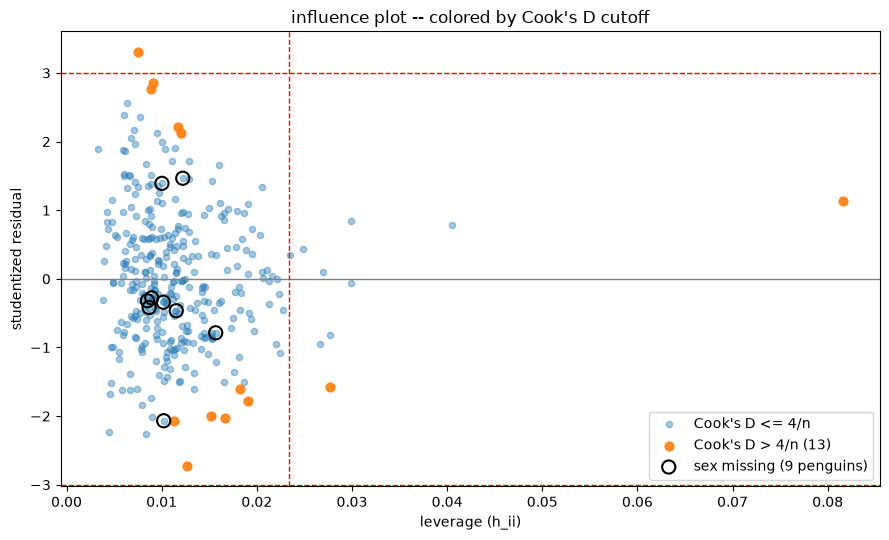

In [23]:
infl_flag = diag.cooks_d > cook_cut

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(diag.leverage[~infl_flag], diag.student_resid[~infl_flag], s=20, alpha=0.4,
           color="tab:blue", label="Cook's D <= 4/n")
ax.scatter(diag.leverage[infl_flag], diag.student_resid[infl_flag], s=40, alpha=0.9,
           color="tab:orange", label=f"Cook's D > 4/n ({infl_flag.sum()})")
ax.scatter(diag.leverage[df_model.sex.isna()], diag.student_resid[df_model.sex.isna()],
           s=90, facecolors='none', edgecolors='black', linewidths=1.5,
           label="sex missing (9 penguins)")
ax.axhline(0, color="gray", lw=1)
for y in (-3, 3):
    ax.axhline(y, color="red", ls="--", lw=1)
ax.axvline(lev_cut, color="red", ls="--", lw=1)
ax.set(xlabel="leverage (h_ii)", ylabel="studentized residual",
       title="influence plot -- colored by Cook's D cutoff")
ax.legend()
plt.tight_layout()
plt.show()

Same kind of plot we made in class. I circled the 9 sex-missing penguins in black so I could see where they land, and they're all just sitting in with the normal blue dots, nowhere near the flagged orange points. More evidence that those 9 penguins aren't doing anything unusual as far as this model is concerned.

### Question 2

In [24]:
bike_diag_model = smf.ols("cnt ~ temp + hum + windspeed + C(season) + C(weathersit)", data=bike).fit()
infl_bike = OLSInfluence(bike_diag_model)
n_b, p_b = int(bike_diag_model.nobs), bike_diag_model.df_model
lev_cut_b, cook_cut_b = 2 * (p_b + 1) / n_b, 4 / n_b

diag_bike = pd.DataFrame({
    "date": bike.dteday, "cnt": bike.cnt,
    "student_resid": infl_bike.resid_studentized_external,
    "leverage": infl_bike.hat_matrix_diag,
    "cooks_d": infl_bike.cooks_distance[0],
})
print(f"leverage cutoff = {lev_cut_b:.4f}   Cook's D cutoff = {cook_cut_b:.4f}")
diag_bike[diag_bike.date.isin(["2012-10-29", "2012-03-17"])].round(4)

leverage cutoff = 0.0246   Cook's D cutoff = 0.0055


,date,cnt,student_resid,leverage,cooks_d
441,2012-03-17,7836,3.2036,0.0166,0.0190
667,2012-10-29,22,-1.5228,0.0547,0.0149


Hurricane Sandy (on 10/29/2012) has really high leverage (0.0547, above the 0.0246 cutoff) and a Cook's D above the cutoff too, but its studentized residual isn't extreme at all (-1.52, nowhere near 3). But this makes sense...the storm probably made that day's weather values (temp/hum/windspeed/weathersit) an unusual combination, which is what gives it high leverage, but the actual ridership (22) wasn't THAT far off from what the model expected once you account for how bad the weather was, so the residual is small.

2012-03-17's datapoint is almost the opposite. It has the single biggest studentized residual in the whole dataset (3.20, just clears the outlier cutoff of 3) and its Cook's D also clears its cutoff, but its leverage (0.0166) is actually a bit under the leverage cutoff. So this day had a much higher ridership (7836) than the model predicted, but its weather values weren't that unusual. It was probably just an unexpectedly nice day that got way more riders than expected.

In [25]:
no_sandy = bike[bike.dteday != "2012-10-29"]
no_0317 = bike[bike.dteday != "2012-03-17"]

model_no_sandy = smf.ols("cnt ~ temp + hum + windspeed + C(season) + C(weathersit)", data=no_sandy).fit()
model_no_0317 = smf.ols("cnt ~ temp + hum + windspeed + C(season) + C(weathersit)", data=no_0317).fit()

sandy_table = pd.DataFrame({
    "all data": bike_diag_model.params,
    "drop 10/29/2012": model_no_sandy.params,
    "pct change": 100 * (model_no_sandy.params - bike_diag_model.params) / bike_diag_model.params.abs(),
})
sandy_table.round(2)

,all data,drop 10/29/2012,pct change
Intercept,3128.94,3099.87,-0.93
C(season)[T.2],926.97,924.05,-0.31
C(season)[T.3],471.32,467.54,-0.80
C(season)[T.4],1496.78,1505.25,0.57
C(weathersit)[T.2],-218.77,-220.74,-0.90
C(weathersit)[T.3],-1902.85,-1815.60,4.59
temp,6205.41,6220.06,0.24
hum,-2635.17,-2621.32,0.53
windspeed,-3330.79,-3258.90,2.16


In [26]:
day_table = pd.DataFrame({
    "all data": bike_diag_model.params,
    "drop 03/17/2012": model_no_0317.params,
    "pct change": 100 * (model_no_0317.params - bike_diag_model.params) / bike_diag_model.params.abs(),
})
day_table.round(2)

,all data,drop 03/17/2012,pct change
Intercept,3128.94,3125.60,-0.11
C(season)[T.2],926.97,980.28,5.75
C(season)[T.3],471.32,544.85,15.60
C(season)[T.4],1496.78,1538.74,2.80
C(weathersit)[T.2],-218.77,-237.06,-8.36
C(weathersit)[T.3],-1902.85,-1916.20,-0.70
temp,6205.41,6085.88,-1.93
hum,-2635.17,-2630.16,0.19
windspeed,-3330.79,-3237.75,2.79


Dropping the Hurricane Sandy day barely changes anything. The biggest shift is only about a 4.6% change in the weathersit=3 coefficient, everything else barely moves. Dropping 2012-03-17 moves things around a little more. The season=3 effect jumps by about 15.6% and season=2 by about 5.75%, but it's still not a dramatic change.

I don't think I'd remove either of these points. Hurricane Sandy is a real, documented event, and a hurricane tanking ridership is what actually happened. And 2012-03-17 might just be an unusually nice day that got more riders than usual. If I had to tell a stakeholder about this, I'd say something like: "we found a couple of unusual days in the data, but removing them doesn't meaningfully change our conclusions, so we kept them in since they reflect real events rather than data entry errors."
***

## Part 5: Feature Transformations

- https://library.virginia.edu/data/articles/interpreting-log-transformations-in-a-linear-model
- https://machinelearningmastery.com/feature-scaling-in-practice-what-works-and-what-doesnt/
- https://scikit-learn.org/stable/data_transforms.html (just sections 8.3.1 and 8.3.3)

All three of these reading tie back to the central idea of normalization and its importance within linear regression. The main idea is to be able to show scaling individual samples on a uniform playing field. The math behind this process also closely ties to the work we perform in Understanding Uncertainty (dot products, matrices, vector scaling). This process is incredibly important within machine learning models, but there are some limitations regarding what kind of algorithm or data we are working with and always requires a great amount of testing and validation. A key example of normalization that we have used twice now is log-log transformations. As the name suggests, it takes the log of your variables and apply it to your visualization. In our class examples, this would most commonly be used to help model skewed data with outliers, which helps us to see similar values closer and extreme values more spread out. 

The question I still wonder is how do we determine if we need to use this form of normalization vs another. One of the articles mentioned there truly isn't an answer to that in real world application, but what kinds of indicators would guide us to look into a log-log normization vs another?